**Assignment no.7:Logistic Regression**

**AIM :
Binary Logistic Regression:1. Predicting binary outcomes using logistic regression in Python.  2. Multinomial Logistic Regression: Predicting outcome with more than two categories using Python.**

**LAB Experiment Example 1:  Fit a binary logistic regression for given dataset and find
y for X = 45. Also find L1 and L2 Regularization coefficients
Sample Data: X (Feature) and y (Target)
X = [[30], [50], [70], [90]]
y = [0, 0, 1, 1]**

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Sample Data
X = np.array([[30], [50], [70], [90]])
y = np.array([0, 0, 1, 1])

print("X (Feature Data):\n", X)
print("y (Target Data):\n", y)

X (Feature Data):
 [[30]
 [50]
 [70]
 [90]]
y (Target Data):
 [0 0 1 1]


### Fit a Binary Logistic Regression Model

We will now fit a basic logistic regression model without explicit regularization first.

In [5]:
# Initialize and fit the Logistic Regression model
# solver='liblinear' is a good choice for small datasets and supports both L1 and L2 penalties
model = LogisticRegression(solver='liblinear')
model.fit(X, y)

print("Model coefficients (beta_1):", model.coef_[0][0])
print("Model intercept (beta_0):", model.intercept_[0])

Model coefficients (beta_1): 0.018195208811995114
Model intercept (beta_0): -0.5285372318030572


### Predict `y` for `X = 45`

Now, let's use the trained model to predict the probability and the class for a new input `X = 45`.

In [3]:
# Predict for X = 45
X_predict = np.array([[45]])

# Predict probabilities
predict_proba = model.predict_proba(X_predict)
print(f"Predicted probabilities for X = 45: {predict_proba}")

# Predict class (0 or 1)
predict_class = model.predict(X_predict)
print(f"Predicted class for X = 45: {predict_class[0]}")

Predicted probabilities for X = 45: [[0.42794336 0.57205664]]
Predicted class for X = 45: 1


### L1 and L2 Regularization Coefficients

Logistic Regression in scikit-learn uses a regularization strength parameter `C`. Smaller values of `C` specify stronger regularization. The penalty can be set to 'l1' for L1 regularization (Lasso) or 'l2' for L2 regularization (Ridge).

- **L1 Regularization (Lasso):** Adds a penalty equal to the absolute value of the magnitude of coefficients. This can lead to sparse models, where some coefficients become exactly zero, effectively performing feature selection.
- **L2 Regularization (Ridge):** Adds a penalty equal to the square of the magnitude of coefficients. This discourages large coefficients, but typically doesn't drive them to zero.

In [4]:
# L1 Regularization (Lasso)
# C is the inverse of regularization strength; smaller C means stronger regularization
model_l1 = LogisticRegression(penalty='l1', C=0.1, solver='liblinear')
model_l1.fit(X, y)

print("\n--- L1 Regularization (C=0.1) ---")
print("L1 Model coefficients (beta_1):", model_l1.coef_[0][0])
print("L1 Model intercept (beta_0):", model_l1.intercept_[0])

# L2 Regularization (Ridge)
model_l2 = LogisticRegression(penalty='l2', C=0.1, solver='liblinear')
model_l2.fit(X, y)

print("\n--- L2 Regularization (C=0.1) ---")
print("L2 Model coefficients (beta_1):", model_l2.coef_[0][0])
print("L2 Model intercept (beta_0):", model_l2.intercept_[0])

# You can experiment with different C values to see the effect of regularization strength


--- L1 Regularization (C=0.1) ---
L1 Model coefficients (beta_1): 0.0075180298928021316
L1 Model intercept (beta_0): 0.0

--- L2 Regularization (C=0.1) ---
L2 Model coefficients (beta_1): 0.011086168649391564
L2 Model intercept (beta_0): -0.05809634248167857


**LAB Experiment Example 2:  
Given Sample Data:  
y_scores = [0.1, 0.4, 0.35, 0.8, 0.76, 0.52, 0.85, 0.3, 0.9, 0.2]
y_true = [0, 0, 1, 1, 1, 0, 1, 0, 1, 0], calculate ROC Curve, AUC Score, Plot AUC Score
for the data.**

In [6]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Given Sample Data
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.76, 0.52, 0.85, 0.3, 0.9, 0.2])
y_true = np.array([0, 0, 1, 1, 1, 0, 1, 0, 1, 0])

print("y_scores (Predicted Probabilities):", y_scores)
print("y_true (True Labels):", y_true)

y_scores (Predicted Probabilities): [0.1  0.4  0.35 0.8  0.76 0.52 0.85 0.3  0.9  0.2 ]
y_true (True Labels): [0 0 1 1 1 0 1 0 1 0]


### Calculate ROC Curve and AUC Score

We will use `roc_curve` to compute the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds, and `auc` to calculate the Area Under the Curve.

In [7]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

print(f"False Positive Rate (FPR): {fpr}")
print(f"True Positive Rate (TPR): {tpr}")
print(f"Thresholds: {thresholds}")
print(f"Area Under the Curve (AUC): {roc_auc:.2f}")

False Positive Rate (FPR): [0.  0.  0.  0.4 0.4 1. ]
True Positive Rate (TPR): [0.  0.2 0.8 0.8 1.  1. ]
Thresholds: [ inf 0.9  0.76 0.4  0.35 0.1 ]
Area Under the Curve (AUC): 0.92


### Plot the ROC Curve

Finally, we will plot the ROC curve to visualize the trade-off between the True Positive Rate and False Positive Rate at various threshold settings, along with the AUC score.

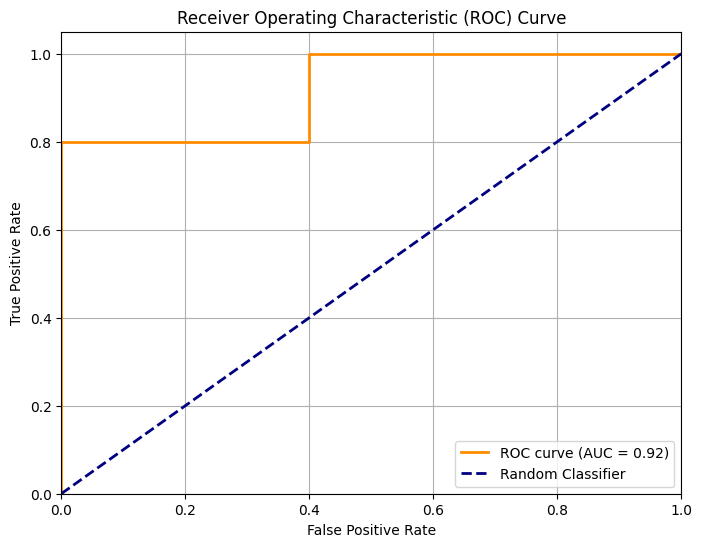

In [8]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**LAB Experiment Example 3:  Randomly generate a dataset and fit a multinomial
logistic regression for the data. give python code for the same and Calculate its metrics
interms of auc, roc scores, f1-score, confusion matrix, recall, accuracy. Also plot them.**

In [9]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

### 1. Generate a Random Dataset for Multinomial Classification

We'll create a synthetic dataset with 3 classes and 2 features using `make_classification`. This allows us to visualize the decision boundaries later if needed.

In [10]:
# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=3,
                           n_clusters_per_class=1, random_state=42)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Number of classes:", np.unique(y).shape[0])

Shape of X: (1000, 2)
Shape of y: (1000,)
Number of classes: 3


### 2. Split Data into Training and Testing Sets

We'll split the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [11]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (700, 2)
X_test shape: (300, 2)
y_train shape: (700,)
y_test shape: (300,)


### 3. Fit a Multinomial Logistic Regression Model

We'll use `LogisticRegression` from scikit-learn, setting `multi_class='multinomial'` to enable true multinomial (softmax) regression. The `solver='lbfgs'` is a good general-purpose solver for this.

In [12]:
# Initialize and fit the Multinomial Logistic Regression model
# Use 'lbfgs' solver for multinomial classification
model_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model_multi.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 4. Calculate and Display Metrics

We'll predict the classes and probabilities on the test set and then calculate various evaluation metrics: Accuracy, Confusion Matrix, Classification Report (which includes Precision, Recall, and F1-score), and ROC AUC scores.

In [13]:
# Predict on the test set
y_pred = model_multi.predict(X_test)
y_pred_proba = model_multi.predict_proba(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report (Precision, Recall, F1-score)
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)

# ROC AUC Score (One-vs-Rest for multinomial)
n_classes = len(np.unique(y_train))
binary_y_test = label_binarize(y_test, classes=np.unique(y_train))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binary_y_test[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr_micro, tpr_micro, _ = roc_curve(binary_y_test.ravel(), y_pred_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

print(f"\nMicro-averaged One-vs-Rest ROC AUC: {roc_auc_micro:.4f}")
for i in range(n_classes):
    print(f"ROC AUC for Class {i}: {roc_auc[i]:.4f}")


Accuracy: 0.8700

Confusion Matrix:
[[85  3 12]
 [15 83  2]
 [ 2  5 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       100
           1       0.91      0.83      0.87       100
           2       0.87      0.93      0.90       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300


Micro-averaged One-vs-Rest ROC AUC: 0.9704
ROC AUC for Class 0: 0.9517
ROC AUC for Class 1: 0.9770
ROC AUC for Class 2: 0.9799


### 5. Plot Metrics

We will visualize the Confusion Matrix as a heatmap and plot the One-vs-Rest ROC curves for each class, along with the micro-averaged ROC curve.

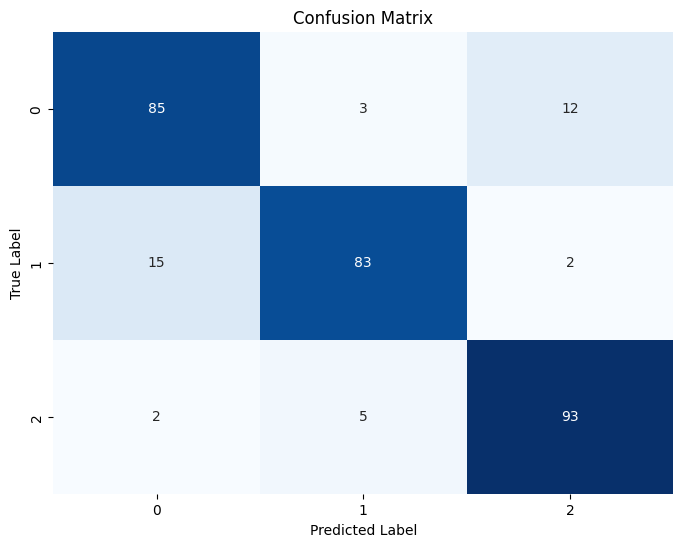

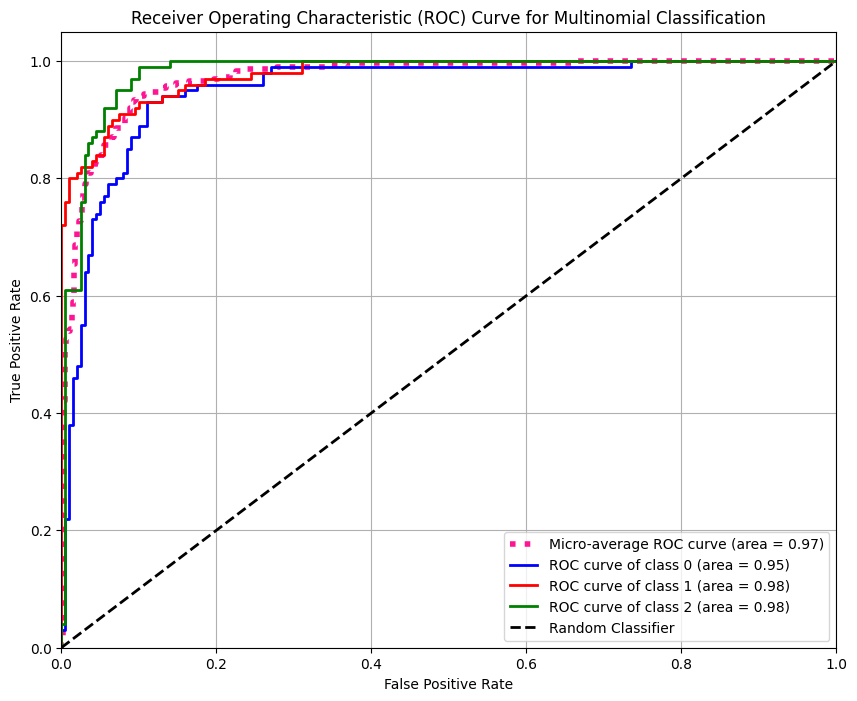

In [14]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot ROC curves (One-vs-Rest)
plt.figure(figsize=(10, 8))
plt.plot(fpr_micro, tpr_micro, label=f'Micro-average ROC curve (area = {roc_auc_micro:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

colors = ['blue', 'red', 'green'] # Define colors for each class
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multinomial Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()